In [2]:
from utils.data_agg import PresentationMapper, DataAggregator
from utils.gazedata import GazeData

In [3]:
import pandas as pd
df_pos = pd.read_csv("data/sentence_position.csv") # with pilot 2 index
df_pos.head() 

,real_index,part_nr,line_idx,text,top,bottom,left,right
0,0,1,0,Il est 4 heures du matin et John est sur le po...,323,368,137,1775
1,0,1,1,lorsqu'il entend des coups de feu.,411,456,514,1398
2,0,2,0,Il sursaute de son lit et regarde par sa fenêtre.,579,624,319,1593
3,1,1,0,Il est 4 heures du matin et Mike s'apprête à a...,191,236,215,1697
4,1,1,1,lorsque soudain il entend un homme crier 'Adie...,279,324,176,1736


In [4]:
mapper2 = PresentationMapper("data/sentences.js", "data/pilot_2/sentence_order_gaze_2.csv")

gaze1 = GazeData("data/pilot_1/pilot1_gaze_2026-06-22_17-40-03 (1).csv")
gaze2 = GazeData("data/pilot_2/gaze_2.csv")
gaze3 = GazeData("data/pilot_3/gaze_2026-06-24_18-05-11.csv")

order1 = "data/pilot_1/pilot1_sentence_order_gaze_2026-06-22_17-40-03 (1).csv"
order2 = "data/pilot_2/sentence_order_gaze_2.csv"
order3 = "data/pilot_3/sentence_order_gaze_2026-06-24_18-05-11.csv"


[PresentationMapper] Initialising...
  real_order_path : data/sentences.js
  exp_order_path  : data/pilot_2/sentence_order_gaze_2.csv
  Loaded 97 sentences from real_order
  First sentence : "Il est 4 heures du matin et John est sur le point de s'endormir lorsqu'il entend des coups de feu."
  Last sentence  : "Magnus doit rejoindre son ami pour prendre un café, il décide de regarder l'heure sur son portable."
  exp_order shape : (97, 2)
  exp_order columns : ['first', 'second']
  Mapping complete. Sample rows:
 presentation_index                                                                                                                                                                                                             first  real_index
                  0                                                                                                                                                                        Eva planifie un city-trip à San Francisco.          66

In [5]:
aggregator = DataAggregator(
    gazedata=[gaze1, gaze2, gaze3],
    real_order_path="data/sentences.js",
    exp_order_paths=[order1, order2, order3],
    df_pos=df_pos,
    sentence_metadata_path="data/combined_valid_sentences.xlsx"
)

# Per participant stats with real_index
df_all = aggregator.compute_gaze_fix_stats()

# Aggregated across participants
df_aggregated = aggregator.aggregate_by_sentence()

[load_sentence_metadata] Loaded 97 sentences

[PresentationMapper] Initialising...
  real_order_path : data/sentences.js
  exp_order_path  : data/pilot_1/pilot1_sentence_order_gaze_2026-06-22_17-40-03 (1).csv
  Loaded 97 sentences from real_order
  First sentence : "Il est 4 heures du matin et John est sur le point de s'endormir lorsqu'il entend des coups de feu."
  Last sentence  : "Magnus doit rejoindre son ami pour prendre un café, il décide de regarder l'heure sur son portable."
  exp_order shape : (97, 2)
  exp_order columns : ['first', 'second']
  Mapping complete. Sample rows:
 presentation_index                                                                                                                                            first  real_index
                  0 Simon est en train de courir pour attraper son bus lorsque son téléphone sonne. Une voix glaciale lui dit qu'un de ses proches a eu un accident.          13
                  1                                 Mik

In [6]:
df_aggregated.head()

,real_index,mean_gaze_samples,std_gaze_samples,mean_fixations,std_fixations,mean_horizontal_fixations,std_horizontal_fixations,n_participants,groupUnc,groupRes,groupVal
0,0,4.000000,5.291503,0.000000,0.00000,0.000000,0.00000,3,high unc conditions,low res conditions,neg conditions
1,1,5.333333,7.571878,0.333333,0.57735,0.000000,0.00000,3,high unc conditions,high res conditions,neg conditions
2,2,0.666667,1.154701,0.000000,0.00000,0.000000,0.00000,3,low unc conditions,high res conditions,pos conditions
3,3,2.000000,3.464102,0.000000,0.00000,0.000000,0.00000,3,high unc conditions,low res conditions,pos conditions
4,4,70.000000,65.574385,0.333333,0.57735,0.666667,0.57735,3,low unc conditions,low res conditions,pos conditions


In [7]:
# Get data for participant 0
df_p1 = df_all[df_all["participant"] == 0]

# Get data for participant 1
df_p2 = df_all[df_all["participant"] == 1]

In [8]:
df_all.head()

,presentation,gaze_samples,fixations,horizontal_fixations,real_index,participant,groupUnc,groupRes,groupVal
0,0,18,1,0,13,0,high unc conditions,low res conditions,neg conditions
1,1,50,0,0,33,0,high unc conditions,low res conditions,neg conditions
2,2,86,0,1,77,0,high unc conditions,high res conditions,neg conditions
3,3,17,0,0,81,0,low unc conditions,low res conditions,neg conditions
4,4,0,0,0,18,0,high unc conditions,high res conditions,neg conditions


# plots !

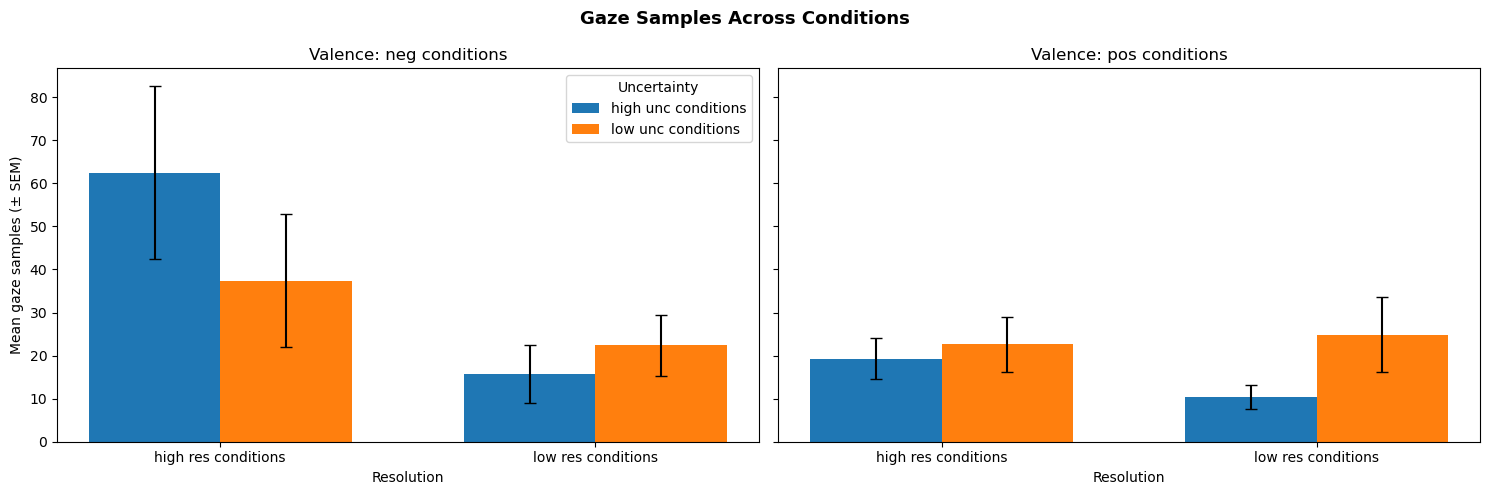

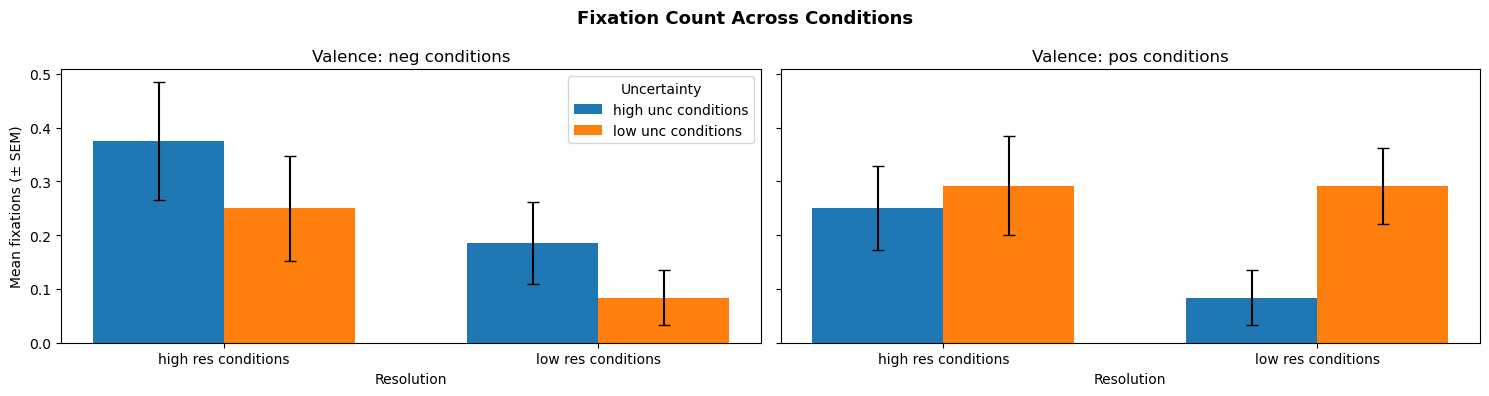

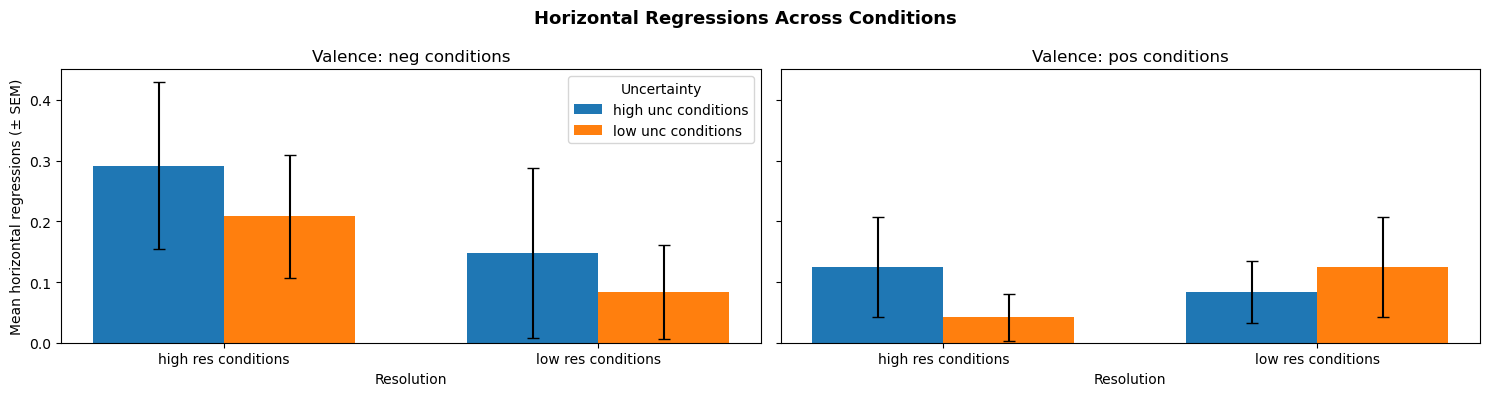

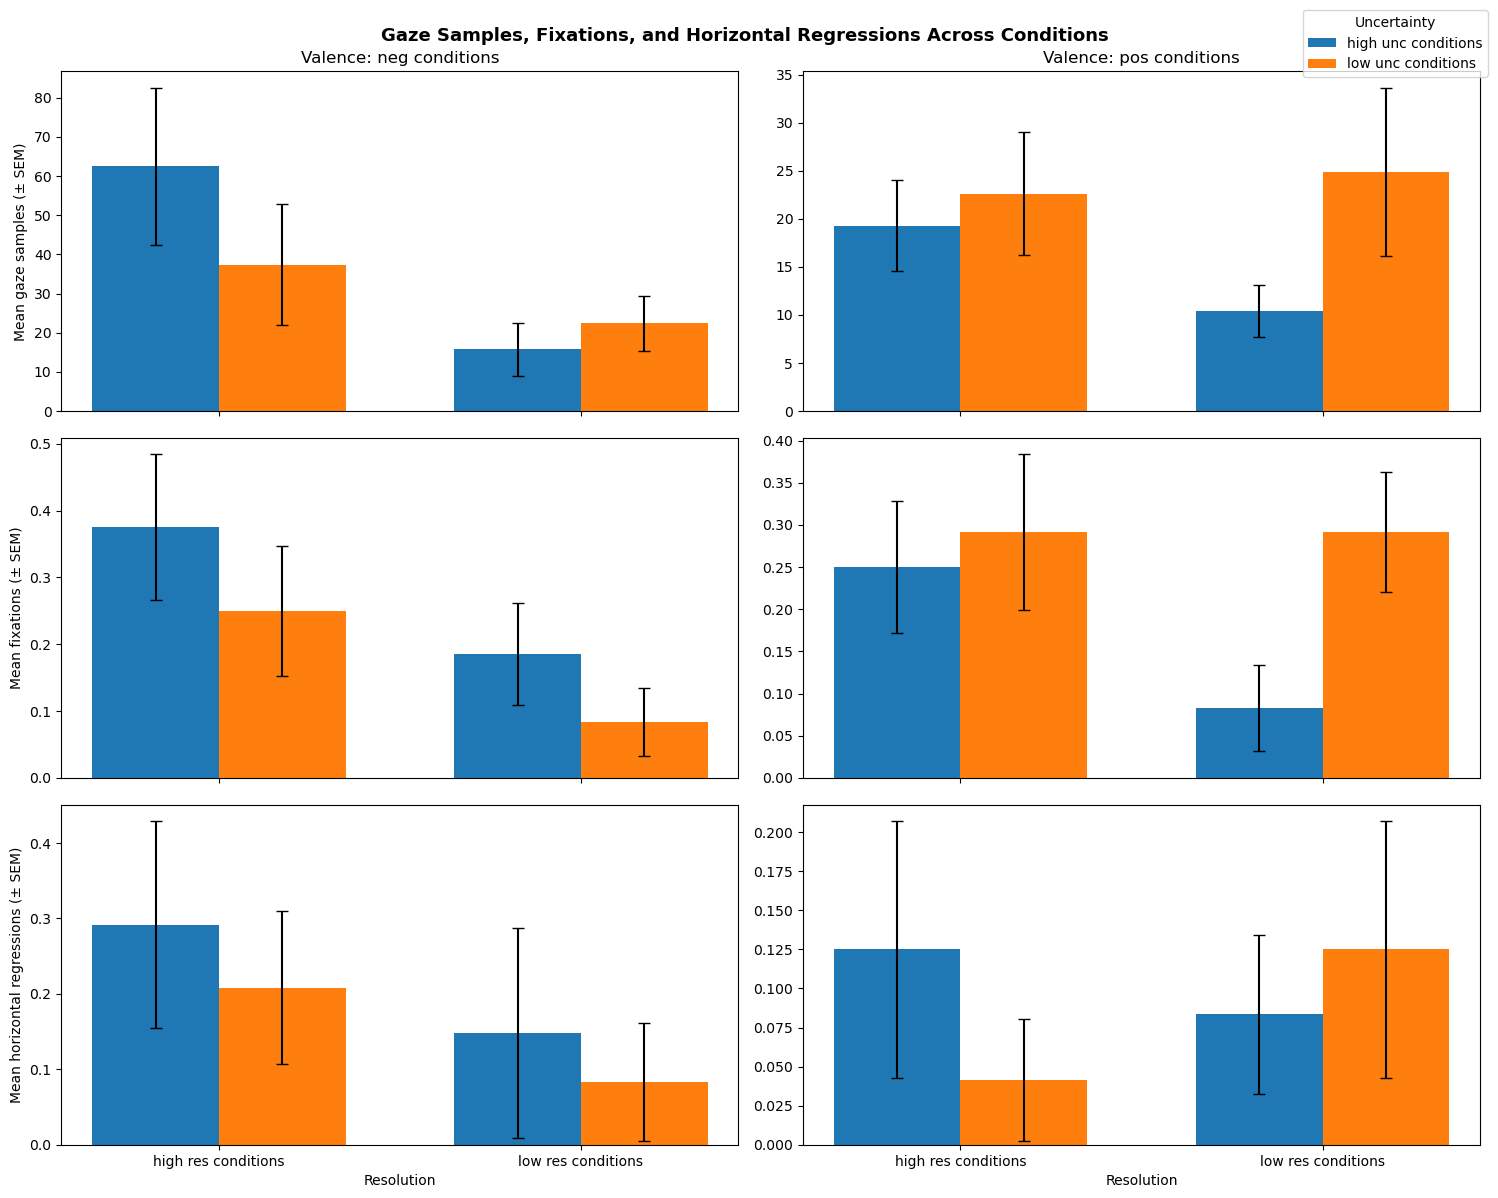

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVING_PATH = "data/figures/"

# Use the aggregated output already computed in the notebook
# Expected columns: real_index, mean_gaze_samples, std_gaze_samples,
# mean_fixations, std_fixations, n_participants, groupUnc, groupRes, groupVal

df = df_aggregated.copy()

required_cols = [
    "real_index",
    "mean_gaze_samples",
    "std_gaze_samples",
    "mean_fixations",
    "std_fixations",
    "mean_horizontal_fixations",
    "std_horizontal_fixations",
    "n_participants",
    "groupUnc",
    "groupRes",
    "groupVal",
]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns in df_aggregated: {missing}")

# Collapse multiple sentence-level rows to one summary row per condition combination
# so the grouped bar chart can be built without duplicate resolution labels.
df = df.dropna(subset=["groupUnc", "groupRes", "groupVal"]).copy()
for col in ["groupUnc", "groupRes", "groupVal"]:
    df[col] = df[col].astype(str)

plot_df = (
    df.groupby(["groupVal", "groupUnc", "groupRes"], as_index=False)
    .agg(
        mean_gaze_samples=("mean_gaze_samples", "mean"),
        std_gaze_samples=("mean_gaze_samples", lambda s: s.std(ddof=0)),
        mean_fixations=("mean_fixations", "mean"),
        std_fixations=("mean_fixations", lambda s: s.std(ddof=0)),
        mean_horizontal_fixations=("mean_horizontal_fixations", "mean"),
        std_horizontal_fixations=("mean_horizontal_fixations", lambda s: s.std(ddof=0)),
        n_participants=("n_participants", "count"),
    )
    .fillna({"std_gaze_samples": 0, "std_fixations": 0, "std_horizontal_fixations": 0})
)

# Make the later plotting helpers use the cleaned summary data.
df = plot_df.copy()

UNC_ORDER = sorted(df["groupUnc"].unique())
RES_ORDER = sorted(df["groupRes"].unique())
VAL_ORDER = sorted(df["groupVal"].unique())

BAR_WIDTH = 0.35
COLORS = {
    "high": "#4C72B0",
    "low": "#DD8452",
    "none": "#55A868",
}


def use_sem(std, n):
    """Convert std to SEM given n_participants."""
    return std / np.sqrt(n)


def plot_metric_by_condition(
    df,
    mean_col,
    std_col,
    title,
    ylabel,
    error_type="sem",
    figsize=(15, 4.5),
):
    """Grouped bar chart: x = groupRes, hue = groupUnc, one subplot per groupVal."""
    fig, axes = plt.subplots(1, len(VAL_ORDER), figsize=figsize, sharey=True)
    if len(VAL_ORDER) == 1:
        axes = [axes]

    x = np.arange(len(RES_ORDER))

    for ax, val in zip(axes, VAL_ORDER):
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)

            means = rows[mean_col].astype(float).values
            stds = rows[std_col].astype(float).values
            n_participants = rows["n_participants"].astype(float).values
            errors = use_sem(stds, n_participants) if error_type == "sem" else stds

            offset = (i - 0.5) * BAR_WIDTH
            ax.bar(
                x + offset,
                means,
                BAR_WIDTH,
                yerr=errors,
                capsize=4,
                label=unc,
                color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_title(f"Valence: {val}")
        ax.set_xlabel("Resolution")
        ax.set_ylim(bottom=0)

    axes[0].set_ylabel(ylabel)
    axes[0].legend(title="Uncertainty")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


# Primary plot: gaze samples across conditions
fig_gaze = plot_metric_by_condition(
    df,
    mean_col="mean_gaze_samples",
    std_col="std_gaze_samples",
    title="Gaze Samples Across Conditions",
    ylabel="Mean gaze samples (± SEM)",
    error_type="sem",
    figsize=(15, 5),
)
fig_gaze.savefig(SAVING_PATH + "gaze_samples_by_condition.png", dpi=200, bbox_inches="tight")

# Secondary plot: fixations across conditions
fig_fix = plot_metric_by_condition(
    df,
    mean_col="mean_fixations",
    std_col="std_fixations",
    title="Fixation Count Across Conditions",
    ylabel="Mean fixations (± SEM)",
    error_type="sem",
    figsize=(15, 4),
)
fig_fix.savefig(SAVING_PATH + "fixations_by_condition.png", dpi=200, bbox_inches="tight")

# Tertiary plot: horizontal (within-line regression) fixations across conditions
fig_horiz = plot_metric_by_condition(
    df,
    mean_col="mean_horizontal_fixations",
    std_col="std_horizontal_fixations",
    title="Horizontal Regressions Across Conditions",
    ylabel="Mean horizontal regressions (± SEM)",
    error_type="sem",
    figsize=(15, 4),
)
fig_horiz.savefig(SAVING_PATH + "horizontal_fixations_by_condition.png", dpi=200, bbox_inches="tight")

# Combined overview for one figure
fig_combined, axes = plt.subplots(3, len(VAL_ORDER), figsize=(15, 12), sharex="col")
x = np.arange(len(RES_ORDER))

for row, (mean_col, std_col, ylabel) in enumerate(
    [
        ("mean_gaze_samples", "std_gaze_samples", "Mean gaze samples (± SEM)"),
        ("mean_fixations", "std_fixations", "Mean fixations (± SEM)"),
        ("mean_horizontal_fixations", "std_horizontal_fixations", "Mean horizontal regressions (± SEM)"),
    ]
):
    for col, val in enumerate(VAL_ORDER):
        ax = axes[row, col]
        sub = df[df["groupVal"] == val]

        for i, unc in enumerate(UNC_ORDER):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(RES_ORDER)
            means = rows[mean_col].astype(float).values
            stds = rows[std_col].astype(float).values
            n_participants = rows["n_participants"].astype(float).values
            errors = use_sem(stds, n_participants)
            offset = (i - 0.5) * BAR_WIDTH
            ax.bar(
                x + offset,
                means,
                BAR_WIDTH,
                yerr=errors,
                capsize=4,
                label=unc if row == 0 and col == 0 else None,
                color=COLORS.get(unc, None),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(RES_ORDER)
        ax.set_ylim(bottom=0)
        if row == 0:
            ax.set_title(f"Valence: {val}")
        if row == 2:
            ax.set_xlabel("Resolution")
        if col == 0:
            ax.set_ylabel(ylabel)

fig_combined.legend(
    *axes[0, 0].get_legend_handles_labels(),
    title="Uncertainty",
    loc="upper right",
    bbox_to_anchor=(1.0, 1.0),
)
fig_combined.suptitle(
    "Gaze Samples, Fixations, and Horizontal Regressions Across Conditions",
    fontsize=13,
    fontweight="bold",
)
fig_combined.tight_layout()
fig_combined.savefig(SAVING_PATH + "combined_gaze_fixations_horizontal_by_condition.png", dpi=200, bbox_inches="tight")

plt.show()

C:\Users\blanc\AppData\Local\Temp\ipykernel_19324\3749571575.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", max(len(unc_order), 1))


C:\Users\blanc\AppData\Local\Temp\ipykernel_19324\3749571575.py:186: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", max(len(unc_order), 1))


C:\Users\blanc\AppData\Local\Temp\ipykernel_19324\3749571575.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", max(len(unc_order), 1))


C:\Users\blanc\AppData\Local\Temp\ipykernel_19324\3749571575.py:186: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", max(len(unc_order), 1))


C:\Users\blanc\AppData\Local\Temp\ipykernel_19324\3749571575.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", max(len(unc_order), 1))


C:\Users\blanc\AppData\Local\Temp\ipykernel_19324\3749571575.py:186: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", max(len(unc_order), 1))
C:\Users\blanc\AppData\Local\Temp\ipykernel_19324\3749571575.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", max(len(participants), 1))
C:\Users\blanc\AppData\Local\Temp\ipykernel_19324\3749571575.py:238: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette 

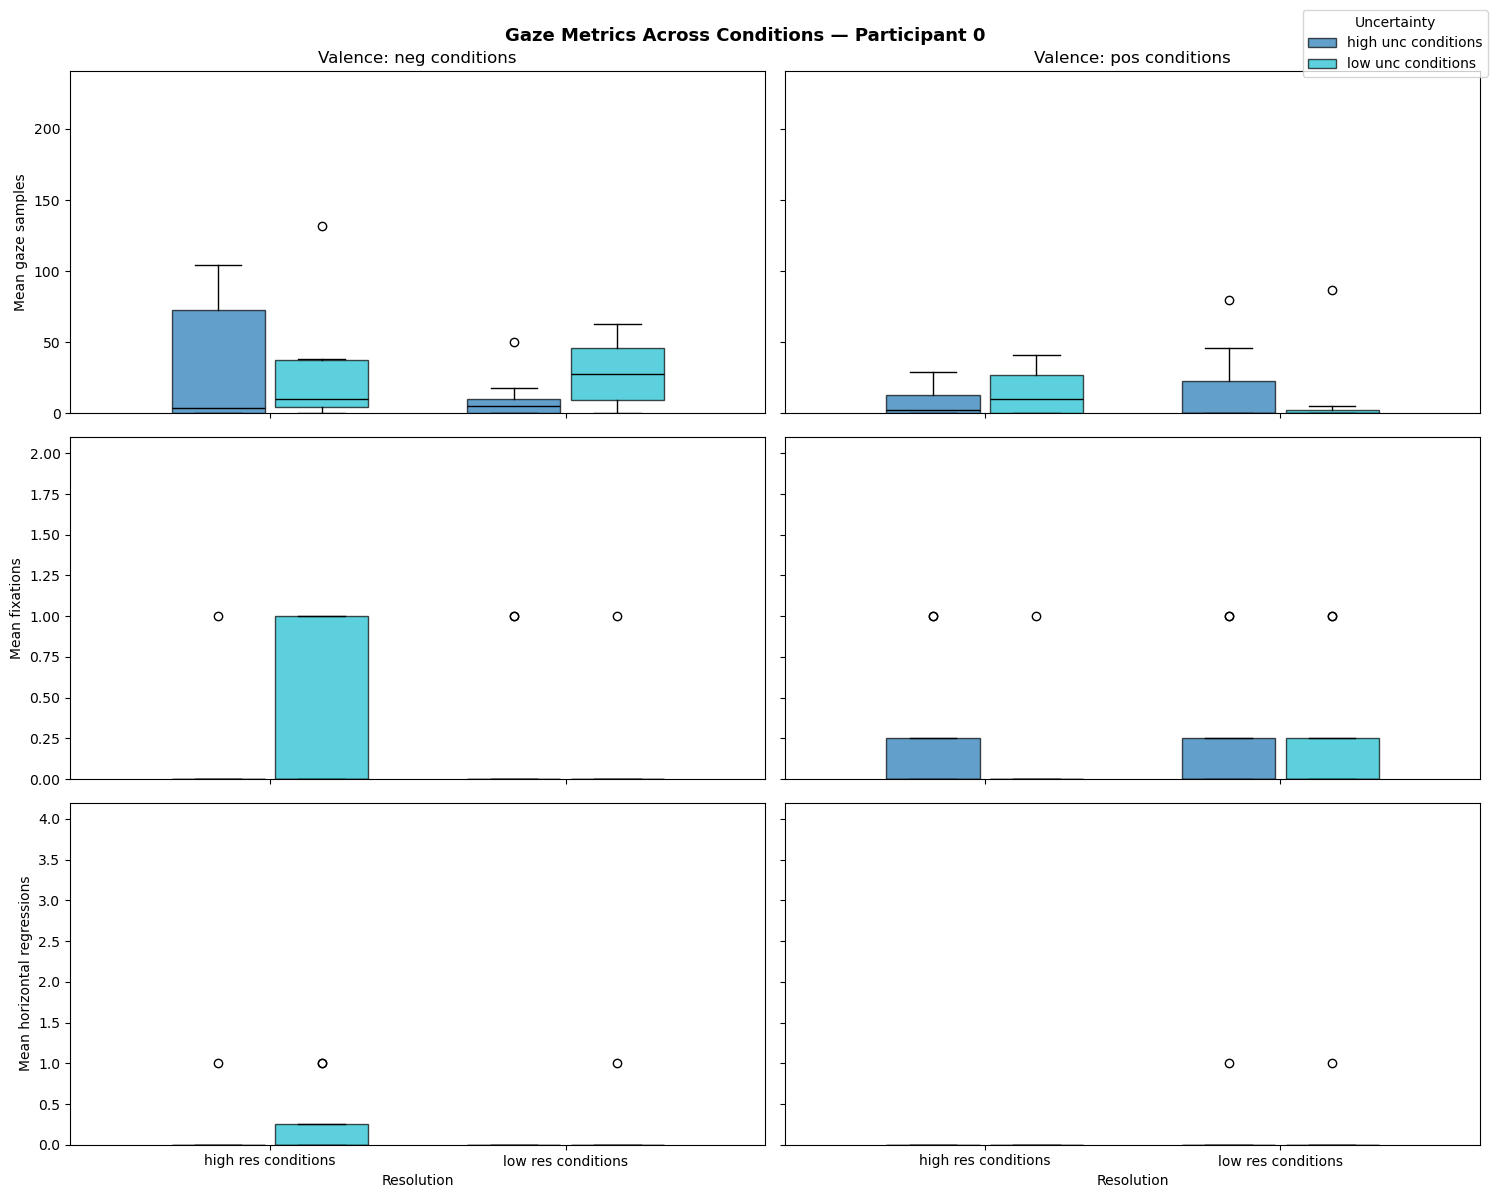

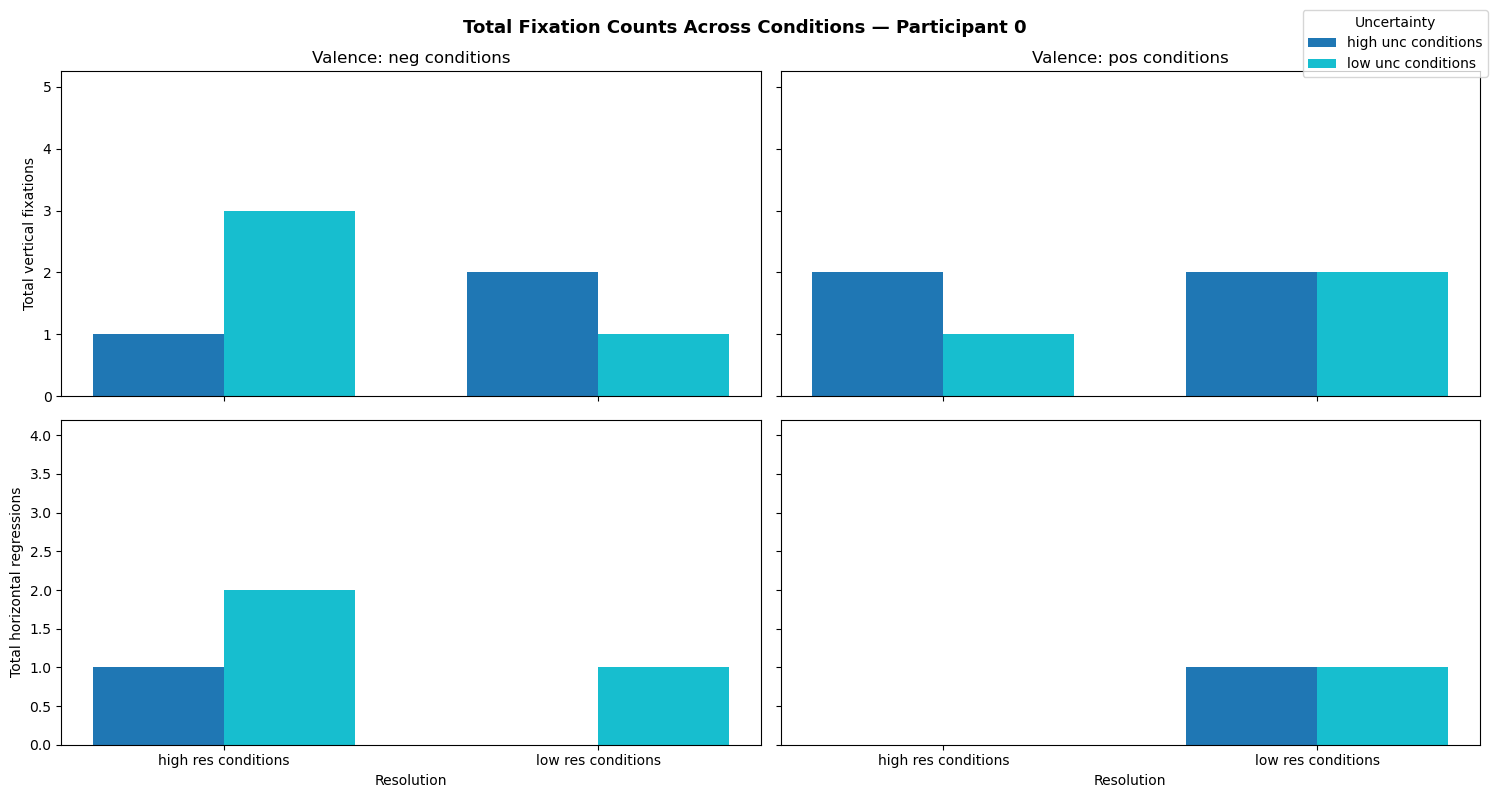

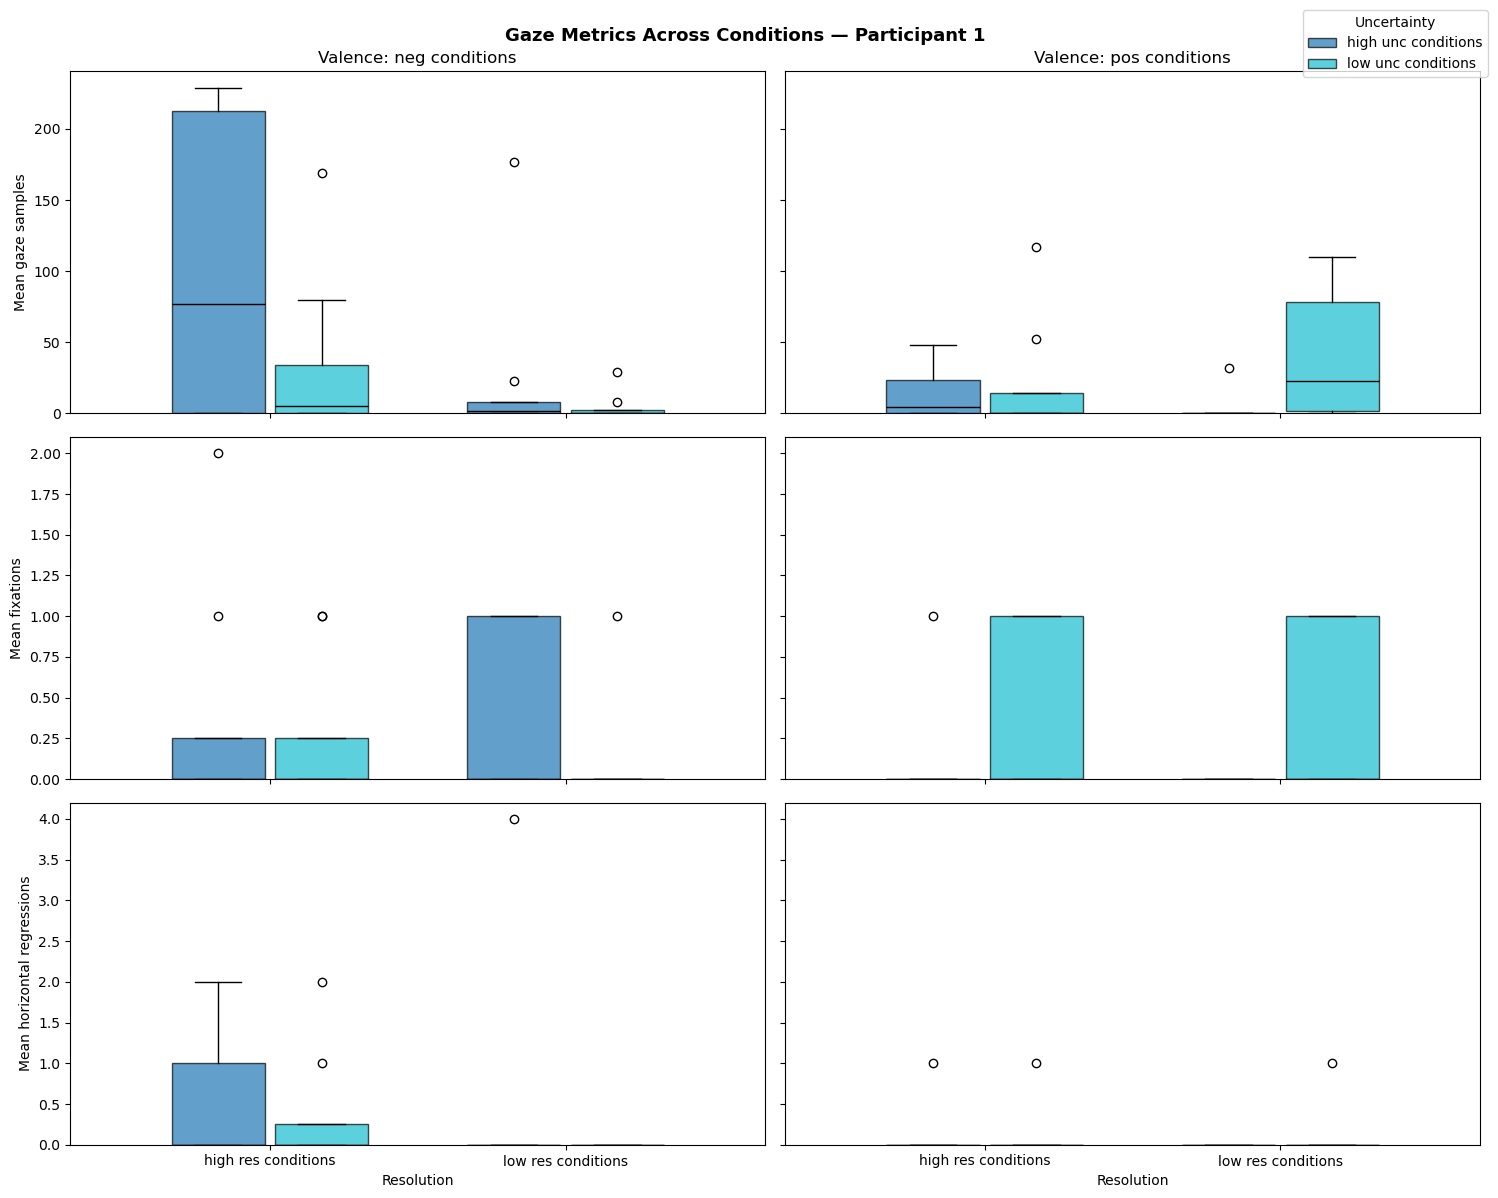

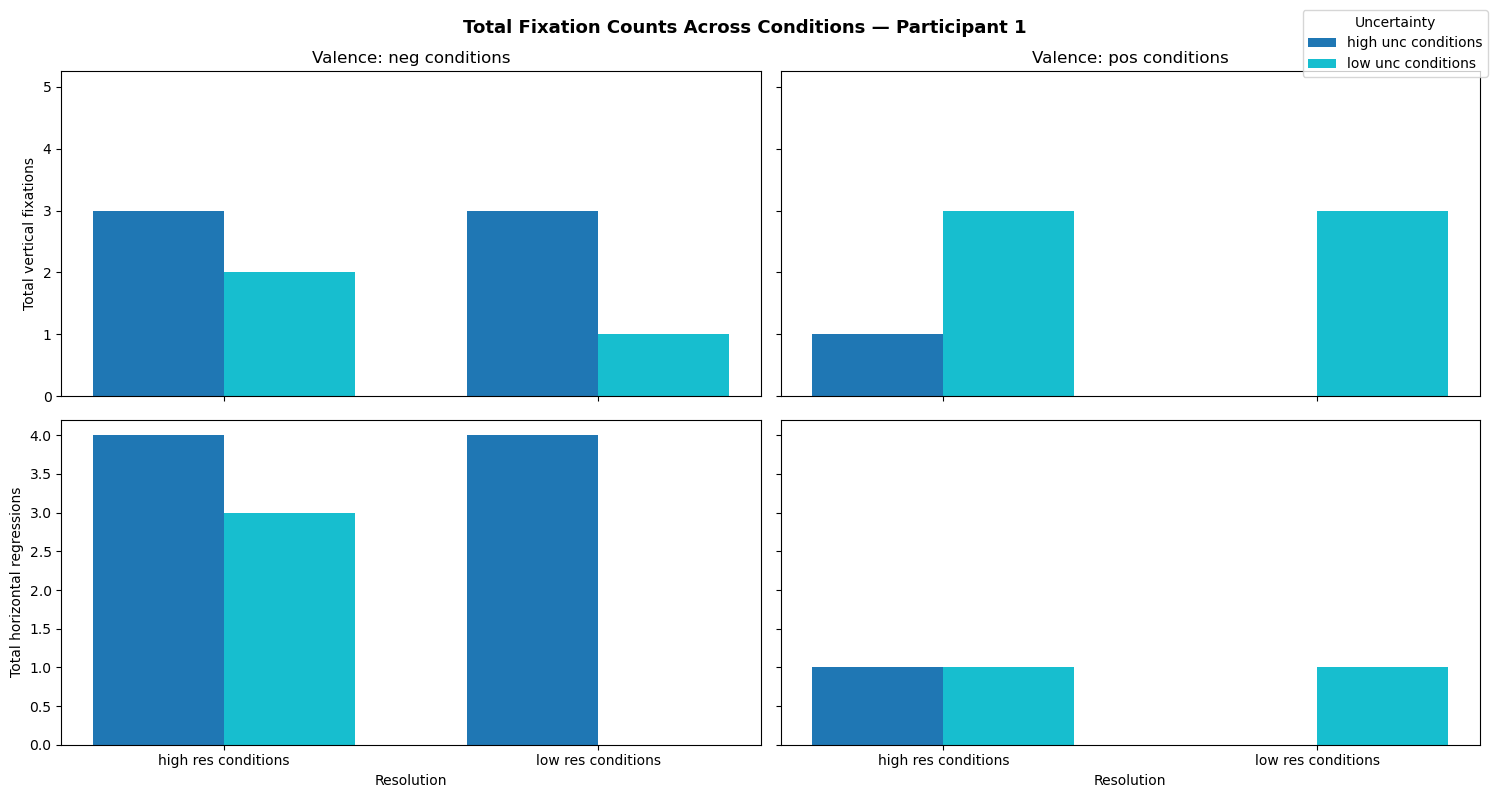

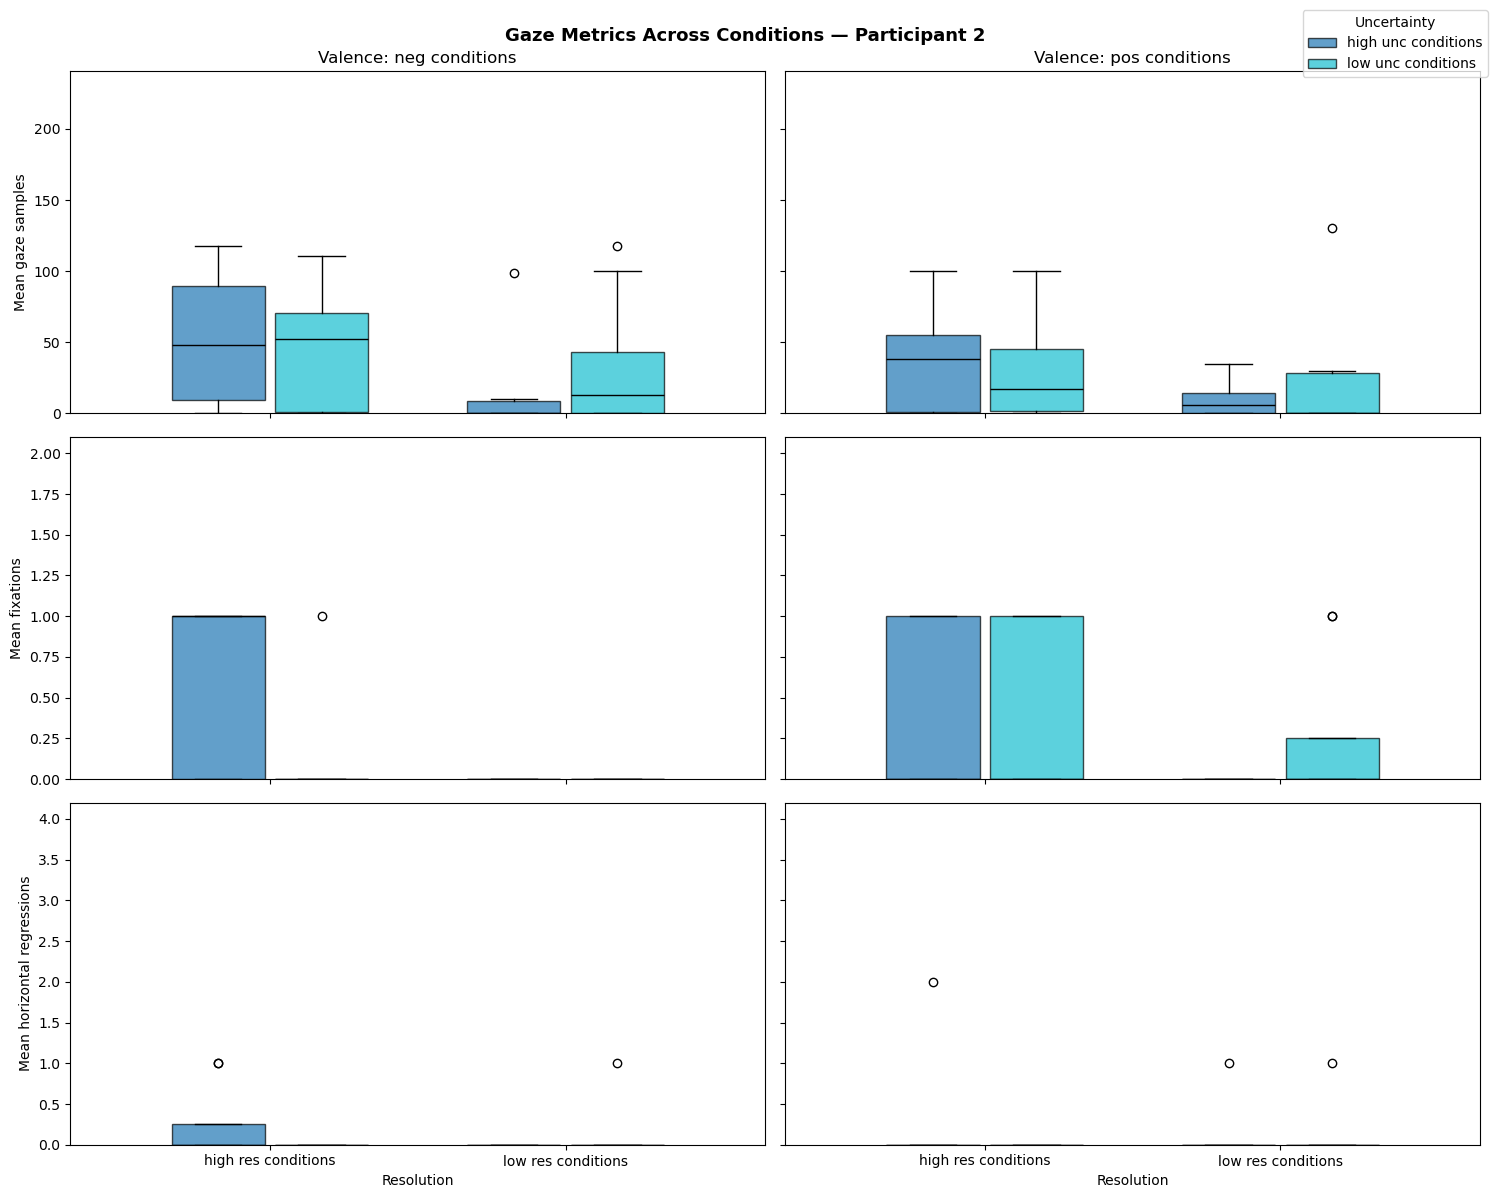

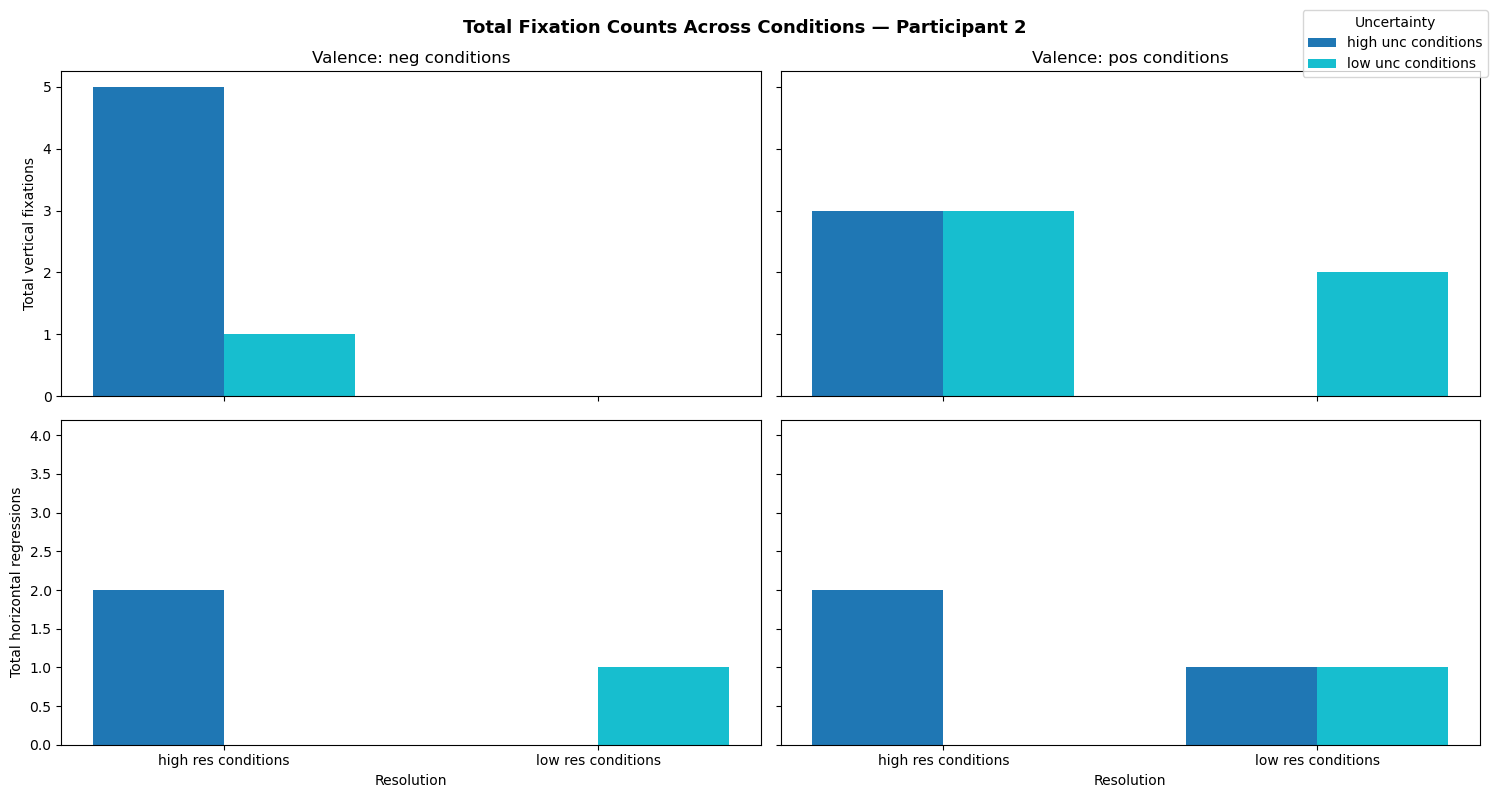

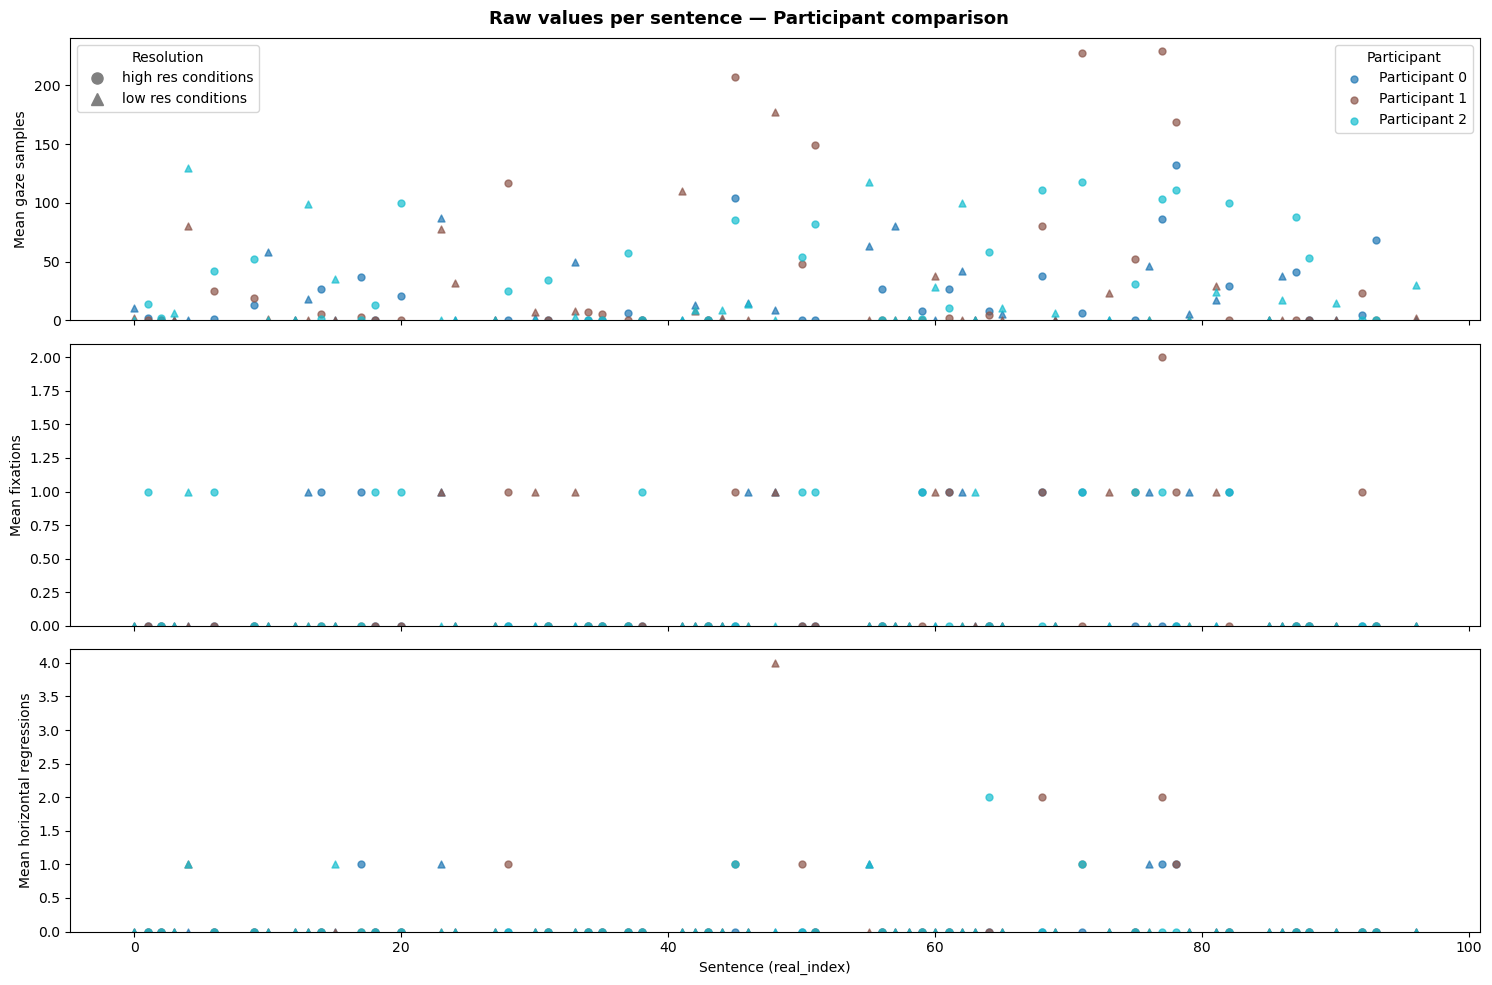

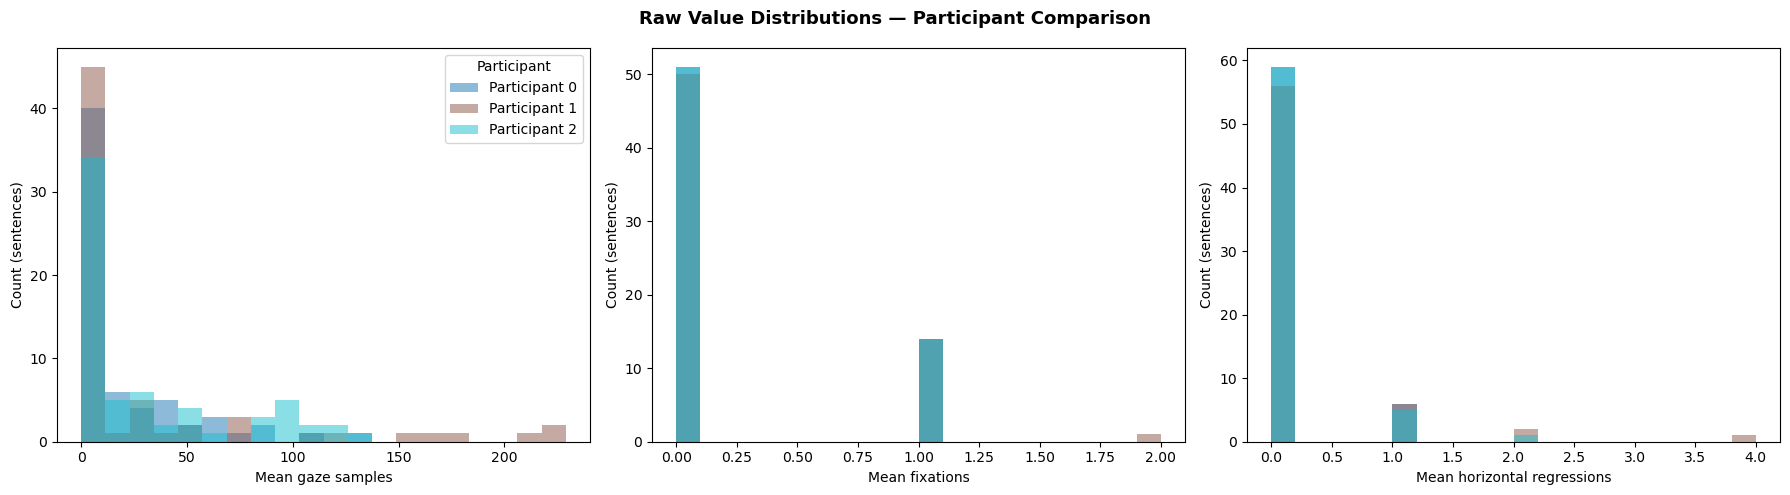

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

SAVING_PATH = "data/figures/"
GROUP_COLS = ["groupVal", "groupUnc", "groupRes"]
METRICS = [
    ("gaze_samples", "Mean gaze samples"),
    ("fixations", "Mean fixations"),
    ("horizontal_fixations", "Mean horizontal regressions"),
]
BAR_WIDTH = 0.35


def compute_global_ylims(df_all, metrics, pad=1.05):
    """Global (0, max*pad) per metric, computed across ALL participants/conditions.
    Used so every participant's figure — and every subplot within it — shares
    the same y-scale for a given metric, making cross-participant comparison valid.
    """
    df = df_all.dropna(subset=GROUP_COLS)
    ylims = {}
    for metric, _ in metrics:
        vmax = df[metric].max()
        vmax = 1 if pd_isna_or_zero(vmax) else vmax
        ylims[metric] = vmax * pad
    return ylims


def pd_isna_or_zero(v):
    return v is None or (isinstance(v, float) and (np.isnan(v) or v == 0))


def compute_global_totals_ylims(df_all, metrics, group_cols=GROUP_COLS, pad=1.05):
    """Global (0, max*pad) per metric for SUMMED (per-participant, per-condition)
    totals, computed across all participants. This is what plot_participant_totals
    needs, since it plots sums rather than raw values.
    """
    df = df_all.dropna(subset=group_cols)
    ylims = {}
    for metric, _ in metrics:
        totals = df.groupby(["participant"] + group_cols)[metric].sum()
        vmax = totals.max() if len(totals) else 1
        vmax = 1 if pd_isna_or_zero(vmax) else vmax
        ylims[metric] = vmax * pad
    return ylims


def plot_participant(df_p, participant_id, ylims, saving_path=SAVING_PATH):
    """One figure per participant: rows = metrics, cols = groupVal. Boxplots per group.
    ylims: dict {metric_name: y_max}, shared across all participants so figures
    are directly comparable.
    """
    n_before = len(df_p)
    df_p = df_p.dropna(subset=GROUP_COLS)
    if len(df_p) < n_before:
        print(f"  WARNING: participant {participant_id} — dropped "
              f"{n_before - len(df_p)} rows with missing condition labels")

    val_order = sorted(df_p["groupVal"].unique())
    unc_order = sorted(df_p["groupUnc"].unique())
    res_order = sorted(df_p["groupRes"].unique())
    x = np.arange(len(res_order))
    box_width = BAR_WIDTH * 0.9

    palette = cm.get_cmap("tab10", max(len(unc_order), 1))
    colors = {unc: palette(i) for i, unc in enumerate(unc_order)}

    fig, axes = plt.subplots(len(METRICS), len(val_order), figsize=(15, 12),
                              sharex="col", sharey="row")

    for row, (metric, ylabel) in enumerate(METRICS):
        for col, val in enumerate(val_order):
            ax = axes[row, col]
            sub = df_p[df_p["groupVal"] == val]

            for i, unc in enumerate(unc_order):
                offset = (i - 0.5) * BAR_WIDTH
                data = [
                    sub[(sub["groupUnc"] == unc) & (sub["groupRes"] == res)][metric].dropna().values
                    for res in res_order
                ]
                bp = ax.boxplot(
                    data, positions=x + offset, widths=box_width,
                    patch_artist=True,
                    medianprops=dict(color="black"),
                )
                for patch in bp["boxes"]:
                    patch.set_facecolor(colors[unc])
                    patch.set_alpha(0.7)
                if row == 0 and col == 0:
                    bp["boxes"][0].set_label(unc)

            ax.set_xticks(x)
            ax.set_xticklabels(res_order)
            ax.set_ylim(0, ylims[metric])
            if row == 0:
                ax.set_title(f"Valence: {val}")
            if row == len(METRICS) - 1:
                ax.set_xlabel("Resolution")
            if col == 0:
                ax.set_ylabel(ylabel)

    fig.legend(*axes[0, 0].get_legend_handles_labels(), title="Uncertainty",
               loc="upper right", bbox_to_anchor=(1.0, 1.0))
    fig.suptitle(f"Gaze Metrics Across Conditions — Participant {participant_id}",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"{saving_path}participant_{participant_id}_gaze_conditions.png",
                dpi=200, bbox_inches="tight")
    return fig


def plot_raw_across_participants(df_all, saving_path=SAVING_PATH):
    """
    One point per sentence (real_index), no aggregation.
    x-axis = real_index, y-axis = raw metric value.
    Color = participant, marker shape = resolution (groupRes),
    so participants and high/low res can both be compared at once.
    """
    df = df_all.dropna(subset=GROUP_COLS + ["real_index"]).sort_values("real_index")

    participants = sorted(df["participant"].unique())
    palette = cm.get_cmap("tab10", max(len(participants), 1))
    colors = {p: palette(i) for i, p in enumerate(participants)}

    res_levels = sorted(df["groupRes"].unique())
    marker_cycle = ["o", "^", "s", "D", "P", "X"]
    markers = {res: marker_cycle[i % len(marker_cycle)] for i, res in enumerate(res_levels)}

    fig, axes = plt.subplots(len(METRICS), 1, figsize=(15, 10), sharex=True)

    for row, (metric, ylabel) in enumerate(METRICS):
        ax = axes[row]
        for p in participants:
            for res in res_levels:
                sub = df[(df["participant"] == p) & (df["groupRes"] == res)]
                ax.scatter(
                    sub["real_index"], sub[metric],
                    color=colors[p], marker=markers[res], alpha=0.7, s=25,
                    label=f"Participant {p}" if row == 0 and res == res_levels[0] else None,
                )
        ax.set_ylabel(ylabel)
        ax.set_ylim(bottom=0)
        if row == len(METRICS) - 1:
            ax.set_xlabel("Sentence (real_index)")

    participant_handles = axes[0].get_legend_handles_labels()
    res_handles = [
        plt.Line2D([0], [0], marker=markers[res], color="gray", linestyle="", markersize=8, label=res)
        for res in res_levels
    ]
    legend1 = axes[0].legend(*participant_handles, title="Participant", loc="upper right")
    axes[0].add_artist(legend1)
    axes[0].legend(handles=res_handles, title="Resolution", loc="upper left")

    fig.suptitle("Raw values per sentence — Participant comparison",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"{saving_path}raw_by_index_participant_comparison.png",
                dpi=200, bbox_inches="tight")
    return fig


TOTAL_METRICS = [
    ("fixations", "Total vertical fixations"),
    ("horizontal_fixations", "Total horizontal regressions"),
]


def plot_participant_totals(df_p, participant_id, ylims, saving_path=SAVING_PATH):
    """One figure per participant: total (summed) counts per condition, rows = metrics, cols = groupVal.
    ylims: dict {metric_name: y_max}, shared across all participants so the total
    fixation-count figures are directly comparable to one another.
    """
    n_before = len(df_p)
    df_p = df_p.dropna(subset=GROUP_COLS)
    if len(df_p) < n_before:
        print(f"  WARNING: participant {participant_id} — dropped "
              f"{n_before - len(df_p)} rows with missing condition labels")

    val_order = sorted(df_p["groupVal"].unique())
    unc_order = sorted(df_p["groupUnc"].unique())
    res_order = sorted(df_p["groupRes"].unique())
    x = np.arange(len(res_order))

    palette = cm.get_cmap("tab10", max(len(unc_order), 1))
    colors = {unc: palette(i) for i, unc in enumerate(unc_order)}

    fig, axes = plt.subplots(len(TOTAL_METRICS), len(val_order), figsize=(15, 8),
                              sharex="col", sharey="row")

    for row, (metric, ylabel) in enumerate(TOTAL_METRICS):
        totals = df_p.groupby(GROUP_COLS)[metric].sum().reset_index()

        for col, val in enumerate(val_order):
            ax = axes[row, col]
            sub = totals[totals["groupVal"] == val]

            for i, unc in enumerate(unc_order):
                rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(res_order)
                offset = (i - 0.5) * BAR_WIDTH
                ax.bar(
                    x + offset, rows[metric].fillna(0), BAR_WIDTH,
                    color=colors[unc],
                    label=unc if row == 0 and col == 0 else None,
                )

            ax.set_xticks(x)
            ax.set_xticklabels(res_order)
            ax.set_ylim(0, ylims[metric])
            if row == 0:
                ax.set_title(f"Valence: {val}")
            if row == len(TOTAL_METRICS) - 1:
                ax.set_xlabel("Resolution")
            if col == 0:
                ax.set_ylabel(ylabel)

    fig.legend(*axes[0, 0].get_legend_handles_labels(), title="Uncertainty",
               loc="upper right", bbox_to_anchor=(1.0, 1.0))
    fig.suptitle(f"Total Fixation Counts Across Conditions — Participant {participant_id}",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"{saving_path}participant_{participant_id}_total_fixations.png",
                dpi=200, bbox_inches="tight")
    return fig


def plot_histograms_across_participants(df_all, bins=20, saving_path=SAVING_PATH):
    """
    One figure, one histogram panel per metric (gaze samples, fixations,
    horizontal fixations). Each participant's distribution is overlaid
    on the same axes so they can be compared directly. Bin edges are
    computed globally per metric so all participants use identical bins.
    """
    df = df_all.dropna(subset=GROUP_COLS)

    participants = sorted(df["participant"].unique())
    palette = cm.get_cmap("tab10", max(len(participants), 1))
    colors = {p: palette(i) for i, p in enumerate(participants)}

    fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 5))

    for col, (metric, ylabel) in enumerate(METRICS):
        ax = axes[col]
        values_all = df[metric].dropna()
        bin_edges = np.histogram_bin_edges(values_all, bins=bins)
        for p in participants:
            values = df[df["participant"] == p][metric].dropna()
            ax.hist(
                values, bins=bin_edges, color=colors[p], alpha=0.5,
                label=f"Participant {p}" if col == 0 else None,
            )
        ax.set_xlabel(ylabel)
        ax.set_ylabel("Count (sentences)")

    axes[0].legend(title="Participant")
    fig.suptitle("Raw Value Distributions — Participant Comparison",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"{saving_path}histograms_participant_comparison.png",
                dpi=200, bbox_inches="tight")
    return fig


# Precompute shared y-axis scales BEFORE looping over participants, so every
# participant's figure (and every subplot within it) uses the same scale.
metric_ylims = compute_global_ylims(df_all, METRICS)
total_ylims = compute_global_totals_ylims(df_all, TOTAL_METRICS)

for pid in sorted(df_all["participant"].unique()):
    plot_participant(df_all[df_all["participant"] == pid], pid, ylims=metric_ylims)
    plot_participant_totals(df_all[df_all["participant"] == pid], pid, ylims=total_ylims)

plot_raw_across_participants(df_all)
plot_histograms_across_participants(df_all)

plt.show()

In [14]:
import numpy as np
import pandas as pd

GROUP_COLS = ["groupVal", "groupUnc", "groupRes"]
FIXATION_METRICS = ["fixations", "horizontal_fixations", "gaze_samples"]

# Path to the file that maps real_index -> sentence text.
SENTENCE_POSITION_PATH = r"C:\Users\blanc\Documents\IASO Master\Internship\processing_data\data\sentence_position.csv"
SENTENCE_TEXT_COL = "text"  # column name inside sentence_position.csv


def load_sentence_text(path=SENTENCE_POSITION_PATH):
    """Load the real_index -> text mapping and return it deduplicated on real_index."""
    sent_df = pd.read_csv(path)
    if "real_index" not in sent_df.columns or SENTENCE_TEXT_COL not in sent_df.columns:
        raise ValueError(
            f"Expected columns 'real_index' and '{SENTENCE_TEXT_COL}' in {path}, "
            f"found: {list(sent_df.columns)}"
        )
    return sent_df.drop_duplicates(subset="real_index")[["real_index", SENTENCE_TEXT_COL]]


def attach_sentence_text(df_all, path=SENTENCE_POSITION_PATH):
    """Merge sentence text onto df_all by real_index (left join, keeps all rows)."""
    sent_df = load_sentence_text(path)
    return df_all.merge(sent_df, on="real_index", how="left")



def _sentence_label_cols(df):
    """Return the list of columns to group by for 'a sentence' (real_index,
    plus the text column if it exists and is present in df)."""
    cols = ["real_index"]
    if SENTENCE_TEXT_COL and SENTENCE_TEXT_COL in df.columns:
        cols.append(SENTENCE_TEXT_COL)
    return cols


def top_sentences_overall(df_all, metric="fixations", top_n=20):
    """
    Which sentences (real_index) have the highest fixation counts,
    averaged across all participants and conditions?
    Useful for: "these sentences are just hard/long, regardless of condition."
    """
    df = df_all.dropna(subset=[metric, "real_index"])
    cols = _sentence_label_cols(df)

    summary = (
        df.groupby(cols)[metric]
        .agg(mean="mean", median="median", std="std", n="count")
        .reset_index()
        .sort_values("mean", ascending=False)
    )
    return summary.head(top_n)


def top_sentences_by_condition(df_all, metric="fixations", top_n=10):
    """
    Within each condition combo (groupVal x groupUnc x groupRes), which
    sentences drive the highest average fixation counts?
    Useful for connecting specific figure differences (e.g. one bar much
    taller than others) back to specific sentences.
    """
    df = df_all.dropna(subset=[metric] + GROUP_COLS + ["real_index"])
    cols = _sentence_label_cols(df)

    results = {}
    for keys, sub in df.groupby(GROUP_COLS):
        summary = (
            sub.groupby(cols)[metric]
            .agg(mean="mean", n="count")
            .reset_index()
            .sort_values("mean", ascending=False)
            .head(top_n)
        )
        results[keys] = summary
    return results


def sentences_driving_participant_outliers(df_all, metric="fixations", z_thresh=2.5):
    """
    Per participant, flags individual sentence-level observations that are
    statistical outliers (z-score beyond z_thresh) for that participant.
    This is what typically compresses shared-axis plots: a handful of
    extreme rows for one participant blow out the y-scale for everyone.
    Returns a single dataframe with a 'participant' column so you can see
    exactly which rows to inspect (or optionally exclude/cap for plotting).
    """
    df = df_all.dropna(subset=[metric, "real_index", "participant"]).copy()
    cols = ["participant", "real_index"] + \
        ([SENTENCE_TEXT_COL] if SENTENCE_TEXT_COL and SENTENCE_TEXT_COL in df.columns else []) + \
        GROUP_COLS + [metric]

    out = []
    for pid, sub in df.groupby("participant"):
        mu, sigma = sub[metric].mean(), sub[metric].std()
        if sigma == 0 or np.isnan(sigma):
            continue
        z = (sub[metric] - mu) / sigma
        flagged = sub.loc[z.abs() >= z_thresh, cols].copy()
        flagged["z_score"] = z[z.abs() >= z_thresh].values
        out.append(flagged)

    if not out:
        return pd.DataFrame(columns=cols + ["z_score"])
    return pd.concat(out, ignore_index=True).sort_values("z_score", ascending=False)


def sentences_driving_condition_gap(df_all, metric="fixations", val_a=None, val_b=None,
                                     group_col="groupVal", top_n=15):
    """
    Given a metric where two condition levels (e.g. groupVal='low' vs 'high')
    show a visible gap in the bar/box plots, this finds the individual
    sentences (real_index) that contribute most to that gap — i.e. the
    biggest per-sentence difference in mean(metric) between the two levels,
    averaged across participants/other conditions.

    If val_a/val_b are None, uses the two most extreme levels found in the data.
    """
    df = df_all.dropna(subset=[metric, "real_index", group_col])
    levels = sorted(df[group_col].unique())
    if val_a is None or val_b is None:
        val_a, val_b = levels[0], levels[-1]

    pivot = (
        df.groupby(["real_index", group_col])[metric]
        .mean()
        .unstack(group_col)
    )
    if val_a not in pivot.columns or val_b not in pivot.columns:
        raise ValueError(f"Levels {val_a!r}/{val_b!r} not found in column {group_col!r}: {levels}")

    pivot["diff"] = pivot[val_b] - pivot[val_a]
    pivot = pivot.sort_values("diff", ascending=False)

    if SENTENCE_TEXT_COL and SENTENCE_TEXT_COL in df.columns:
        text_lookup = df.drop_duplicates("real_index").set_index("real_index")[SENTENCE_TEXT_COL]
        pivot = pivot.join(text_lookup)

    return pivot.reset_index().head(top_n), pivot.reset_index().tail(top_n)


if __name__ == "__main__":
    # Attach the actual sentence text (from sentence_position.csv) by real_index
    # before running any of the analyses below, so all outputs include the text.
    df_all = attach_sentence_text(df_all)

    for metric in FIXATION_METRICS:

        print(f"\n=== Top sentences overall — {metric} ===")
        print(top_sentences_overall(df_all, metric=metric, top_n=15).to_string(index=False))

    print("\n=== Sentences flagged as per-participant outliers (fixations) ===")
    outliers = sentences_driving_participant_outliers(df_all, metric="fixations", z_thresh=2.5)
    print(outliers.to_string(index=False))
    outliers.to_csv("data/figures/outlier_sentences_fixations.csv", index=False)

    print("\n=== Sentences driving the biggest groupVal gap (fixations) ===")
    top_high, top_low = sentences_driving_condition_gap(df_all, metric="fixations", group_col="groupVal")
    print("Highest positive diff (val_b - val_a):")
    print(top_high.to_string(index=False))
    print("\nHighest negative diff:")
    print(top_low.to_string(index=False))


=== Top sentences overall — fixations ===
 real_index                                                           text     mean  median      std  n
         77       Megan est en train de bronzer sur son bateau lorsqu'elle 1.000000     1.0 1.000000  3
         53                             Mady fait la fête au centre-ville. 0.666667     1.0 0.577350  3
         68    Lorena est en retard pour son rendez-vous. Elle s'apprête à 0.666667     1.0 0.577350  3
         75      Kim veut partir en voyage mais elle ne sait pas encore où 0.666667     1.0 0.577350  3
         71  Jim habite seul et il rentre tous les jours du travail à 19h. 0.666667     1.0 0.577350  3
         61   Emmanuel est supposé rejoindre son ami pour prendre un verre 0.666667     1.0 0.577350  3
         59       Olivia fait un tour touristique lorsque quelque chose de 0.666667     1.0 0.577350  3
         94                                          Erin voyage en avion. 0.666667     0.0 1.154701  3
         82  Sara a t